## DBSCAN

*"Density based spatial clustering of applications with noise"*

In [1]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=1000, noise= 0.05)
dbscan= DBSCAN(eps= 0.05, min_samples= 5)
dbscan.fit(X)

DBSCAN(eps=0.05)

In [2]:
dbscan.labels_

array([ 0,  2,  1,  2,  3,  1,  8,  2,  4,  2, -1,  1,  1,  1,  1,  1,  5,
        6,  2,  4,  1, -1,  7,  3,  0,  6,  1,  4,  2,  5,  1, 11, -1,  8,
        1,  0, -1,  1,  8, 13,  0,  4,  9, -1,  1,  2, -1,  0,  0,  6, -1,
        3,  1, -1,  1,  1,  1, -1,  2,  4,  1,  6,  0,  3,  1,  2,  1,  2,
        3,  8,  1,  8,  2,  5,  2,  1,  3,  3,  3,  1,  2,  5, -1,  1, -1,
        2, -1, -1, 10,  1, -1,  1,  6,  1, 12, -1,  1,  8,  1,  1,  1,  1,
        1,  7,  1, 11,  6,  7,  8,  2,  1,  5, -1,  8,  6,  1,  1,  6,  1,
        1,  6,  6,  2,  5,  3,  5, 12,  0,  1,  1,  3,  0,  3,  0,  8,  2,
        1,  6,  4,  3,  1,  8,  1,  2,  6,  7,  3,  7, -1,  7, -1,  2,  0,
       12,  5,  0,  1,  1,  1,  1,  0,  0,  6,  3, -1, -1,  3, -1,  1,  1,
        2,  1,  6,  5, -1,  2,  1,  2,  5,  2,  2,  2,  3,  1, -1,  3,  4,
        8,  8,  1,  0,  1,  3,  1,  7,  3,  3,  1,  3,  2,  3,  1,  1,  6,
        1,  3,  1,  5, 13,  8,  2,  3,  3,  8,  1,  3,  6,  9,  1,  1,  6,
        9,  1,  3,  0,  1

In [3]:
dbscan.core_sample_indices_

array([  0,   2,   3,   4,   5,   7,   8,   9,  11,  12,  13,  14,  16,
        17,  18,  19,  22,  23,  24,  25,  26,  27,  28,  29,  30,  33,
        34,  35,  37,  38,  40,  41,  42,  45,  48,  49,  51,  52,  54,
        58,  61,  62,  63,  64,  67,  68,  69,  70,  72,  73,  74,  75,
        76,  79,  80,  83,  85,  88,  89,  92,  93,  96,  97,  98,  99,
       101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 113, 114, 115,
       116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 146, 147, 149, 151, 152, 153, 154, 155, 156, 157, 158,
       159, 160, 161, 162, 163, 166, 168, 169, 170, 171, 172, 173, 177,
       178, 181, 182, 183, 185, 186, 187, 188, 190, 191, 192, 194, 195,
       196, 197, 199, 200, 201, 202, 203, 204, 205, 206, 207, 209, 210,
       211, 212, 213, 214, 215, 216, 217, 219, 221, 222, 223, 225, 226,
       227, 228, 229, 231, 232, 235, 237, 239, 240, 242, 243, 24

In [4]:
dbscan.core_sample_indices_.shape

(774,)

774 out of 1000 as core instances.. too mmuch?

In [5]:
dbscan.components_

array([[ 0.00597544,  0.17837432],
       [ 0.9546349 ,  0.33615655],
       [ 1.92470179,  0.05784344],
       ...,
       [ 1.34722958, -0.47731   ],
       [-0.6542709 ,  0.75304584],
       [ 0.07203667,  0.99110012]])

In [6]:
dbscan.labels_.shape

(1000,)

In [8]:
X.shape

(1000, 2)

In [9]:
y.shape

(1000,)

In [10]:
copy= dbscan.labels_

In [13]:
sum(copy != -1)

906

That means that there are 94 anomalies in our dataset.. 774 core instances.. that leaves 132 datapoints that are neither core instances nor anomalies.. they just exist

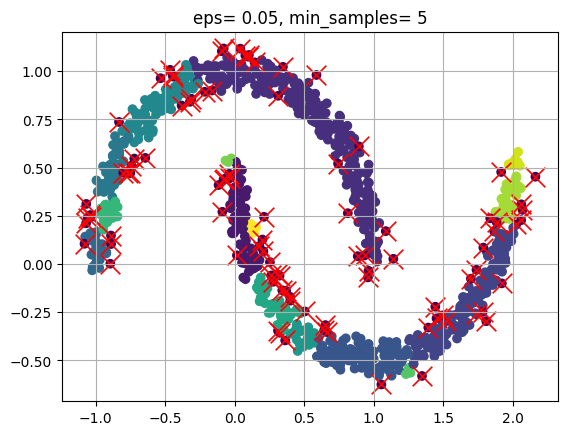

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

plt.scatter(X[:,0], X[:,1], c= dbscan.labels_, cmap = "viridis")

## setting the red markers

plt.title("eps= 0.05, min_samples= 5")
plt.grid()


i = 200          # point whose neighbourhood you want to show

plt.scatter(X[:,0], X[:,1], c=dbscan.labels_)
plt.scatter(
    X[i,0], X[i,1],
    c='red',
    s=120,
    edgecolor='black',
    zorder=5
)

circle = Circle(
    (X[i,0], X[i,1]),
    radius=dbscan.eps,
    fill=False,
    color='red',
    linestyle='--',
    linewidth=2
)

plt.gca().add_patch(circle)

plt.axis('equal')   # makes the circle actually circular
plt.grid()

In [ ]:
from matplotlib.patches import Circle

i = 50  # choose any point

# Points
plt.scatter(X[:,0], X[:,1], c="steelblue")

# Highlight anomalies (DBSCAN labels = -1)
noise = dbscan.labels_ == -1
plt.scatter(X[noise,0], X[noise,1],
            c="red", marker="x", s=80, label="Anomalies")

# Chosen point
plt.scatter(X[i,0], X[i,1],
            c="black", s=100)

# ε-neighbourhood
circle = Circle((X[i,0], X[i,1]),
                radius=dbscan.eps,
                fill=False,
                color="green",
                linewidth=2)

plt.gca().add_patch(circle)

plt.axis("equal")
plt.grid(True)
plt.legend()

In [27]:
X.shape

(1000, 2)

In [30]:
len(X)

1000

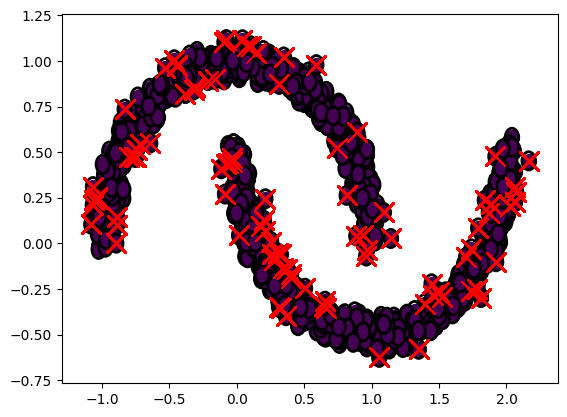

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

def plot_clusters(dbs, X):
    labels = dbs.fit_predict(X)
    for i in range (0, len(X)):
        plt.scatter(X[i,0], X[i,1], c=labels[i], s=100)

        # ε-neighbourhood
        circle = Circle((X[i,0], X[i,1]),
                        radius=dbs.eps,
                        fill=False,
                        linewidth=2)

        plt.gca().add_patch(circle)

        mask = (labels == -1)
        plt.scatter(X[mask, 0], X[mask, 1], marker= 'x', c= 'red', s= 200, linewidth= 1.2, )

plot_clusters(dbscan, X)

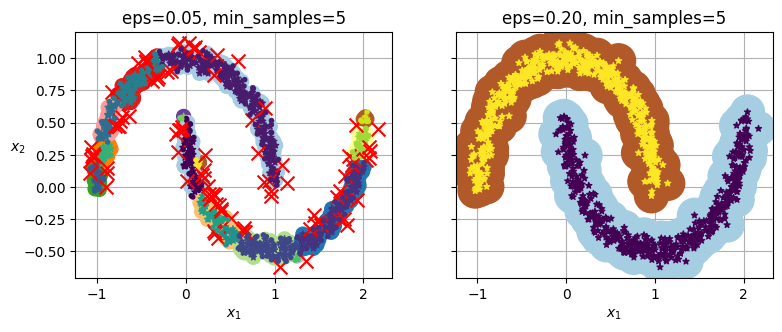

In [34]:
def plot_dbscan(dbscan, X, size, show_xlabels=True, show_ylabels=True):
    core_mask = np.zeros_like(dbscan.labels_, dtype=bool)
    core_mask[dbscan.core_sample_indices_] = True
    anomalies_mask = dbscan.labels_ == -1
    non_core_mask = ~(core_mask | anomalies_mask)

    cores = dbscan.components_
    anomalies = X[anomalies_mask]
    non_cores = X[non_core_mask]
    
    plt.scatter(cores[:, 0], cores[:, 1],
                c=dbscan.labels_[core_mask], marker='o', s=size, cmap="Paired")
    plt.scatter(cores[:, 0], cores[:, 1], marker='*', s=20,
                c=dbscan.labels_[core_mask])
    plt.scatter(anomalies[:, 0], anomalies[:, 1],
                c="r", marker="x", s=100)
    plt.scatter(non_cores[:, 0], non_cores[:, 1],
                c=dbscan.labels_[non_core_mask], marker=".")
    if show_xlabels:
        plt.xlabel("$x_1$")
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", rotation=0)
    else:
        plt.tick_params(labelleft=False)
    plt.title(f"eps={dbscan.eps:.2f}, min_samples={dbscan.min_samples}")
    plt.grid()
    plt.gca().set_axisbelow(True)

dbscan2 = DBSCAN(eps=0.2)
dbscan2.fit(X)

plt.figure(figsize=(9, 3.2))

plt.subplot(121)
plot_dbscan(dbscan, X, size=100)

plt.subplot(122)
plot_dbscan(dbscan2, X, size=600, show_ylabels=False)

plt.show()
